# CIV4 Who's Where - Dataset Inspection

## Goal of this notebook
This notebook is the first step for a CNN pipeline based on a pretrained PyTorch model to identify and classify ground-dwelling animal groups from drone-view imagery.

## Available data
- RGB images: `data/rgb_images/{train,val,test}`
- Matched labels: `data/labels_matched_rgb/{train,val,test}`
- Label format: one `.txt` file per image frame using YOLO format
  - `class_id x_center y_center width height`
  - all coordinates are normalized to `[0, 1]` relative to image size

## Plan

- We don't care about order
- So find groups/clusters of animals
- lable the group with animal type
- cut out animal type!
- save in folder of animal type
- anotate cutouts
- 

## Looking at an image

**What this section does**

1. Load one sample image-label pair (`104_1545`).
2. Convert normalized YOLO coordinates into pixel coordinates.
3. Draw and display bounding boxes directly on the image.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd

In [7]:
headings = []
with open("../data/gt_headings.txt", "r") as f:
    headings = f.readline().split(";")

101.922304 683.147776 44.669952 44.004352
928.7997439999999 377.099776 52.299776 44.499968
240.76288 704.9789440000001 44.326912 44.468224


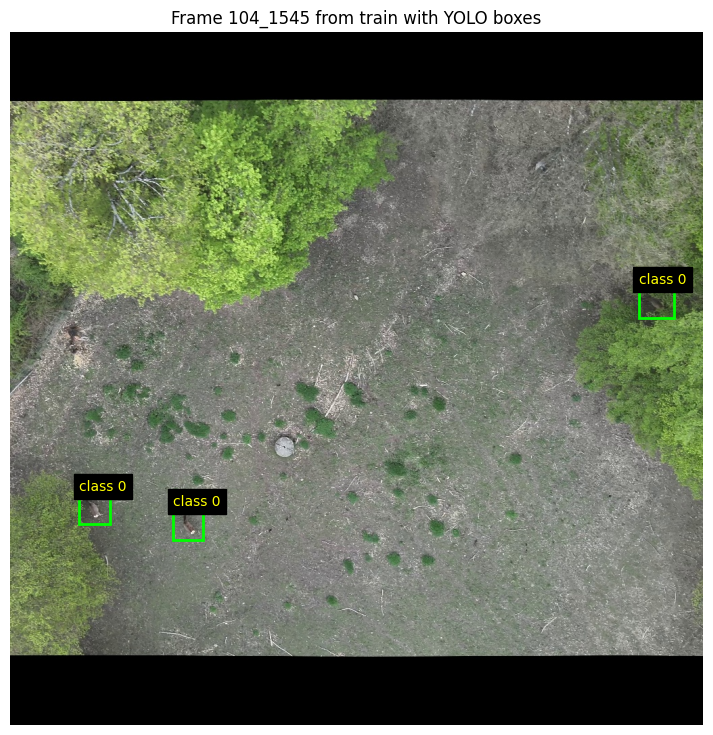

Split: train
Image size: 1024 x 1024
Label file: 104_1545.txt
Number of boxes: 3


In [8]:
def yolo_to_xyxy(x_center, y_center, width, height, image_width, image_height):
    x_center_px = x_center * image_width
    y_center_px = y_center * image_height
    width_px = width * image_width
    height_px = height * image_height

    x_min = x_center_px - (width_px / 2)
    y_min = y_center_px - (height_px / 2)
    return x_min, y_min, width_px, height_px


def resolve_frame_paths(frame_id, project_root):
    """Find the split (train/val/test) where both image and label exist for a frame."""
    for split in ("train", "val", "test"):
        image_path = project_root / "data" / "rgb_images" / split / f"{frame_id}.jpg"
        label_path = project_root / "data" / "labels_matched_rgb" / split / f"{frame_id}.txt"
        if image_path.exists() and label_path.exists():
            return split, image_path, label_path

    raise FileNotFoundError(
        f"Could not find matching JPG and TXT for frame '{frame_id}' in train/val/test."
    )


def show_frame_with_boxes(frame_id, project_root=None):
    """Load a frame by id, auto-detect split, and visualize YOLO boxes."""
    if project_root is None:
        cwd = Path.cwd().resolve()
        project_root = cwd.parent if cwd.name == "notebooks" else cwd

    split, image_path, label_path = resolve_frame_paths(frame_id, project_root)

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    boxes = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id, x_c, y_c, w, h = line.split()
            boxes.append((int(class_id), float(x_c), float(y_c), float(w), float(h)))

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)

    for class_id, x_c, y_c, w, h in boxes:
        x_min, y_min, box_w, box_h = yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
        print(x_min, y_min, box_w, box_h)
        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x_min, max(y_min - 6, 2), f"class {class_id}", color="yellow", fontsize=10, backgroundcolor="black")

    ax.set_title(f"Frame {frame_id} from {split} with YOLO boxes")
    ax.axis("off")
    plt.show()

    print(f"Split: {split}")
    print(f"Image size: {img_w} x {img_h}")
    print(f"Label file: {label_path.name}")
    print(f"Number of boxes: {len(boxes)}")

    return {
        "split": split,
        "image_path": image_path,
        "label_path": label_path,
        "image_size": (img_w, img_h),
        "num_boxes": len(boxes),
        "boxes": boxes,
    }


# Demo: show the same frame currently used in this notebook.
frame_info = show_frame_with_boxes("104_1545")

In [14]:
frame_id = "104"
gt = pd.read_csv(f"../data/gt/{frame_id}_gt.txt", names=headings)
gt[gt["frame"] == 1545]

,frame,track_id,bb_left,bb_top,bb_width,bb_height,conf,class_id,visibility,species,gender,age,is_propagated
212,1545,1823,243,707,51,53,1.0,7,1.0,Cervus elaphus (Red deer),1,2,0
213,1545,1824,100,684,42,50,1.0,5,1.0,Cervus elaphus (Red deer),0,2,0
214,1545,1825,970,372,54,40,1.0,12,0.5,Cervus elaphus (Red deer),2,2,0


In [16]:
def match_gt_to_txt_boxes(
    gt_df,
    frame_id,
    frame_number,
    project_root=None,
    image_size=(1024, 1024),
    min_iou=0.0,
):
    """Match GT pixel boxes to YOLO txt boxes for one frame without loading images.

    Args:
        gt_df: DataFrame containing GT rows with columns frame, bb_left, bb_top, bb_width, bb_height.
        frame_id: Prefix used in GT file naming (e.g., "1").
        frame_number: Frame number inside GT table (e.g., 11726).
        project_root: Project root path. Auto-detected if None.
        image_size: (width, height) used to convert YOLO normalized coords to pixels.
        min_iou: Minimum IoU required to keep a match.

    Returns:
        dict with:
            - matches_df: one row per GT box with best txt match (or no match)
            - txt_boxes_df: parsed txt boxes in pixel coords
            - label_path: matched txt label path
            - split: dataset split where txt was found
    """
    if project_root is None:
        cwd = Path.cwd().resolve()
        project_root = cwd.parent if cwd.name == "notebooks" else cwd

    frame_key = f"{frame_id}_{frame_number}"
    split = None
    label_path = None
    for s in ("train", "val", "test"):
        candidate = project_root / "data" / "labels_matched_rgb" / s / f"{frame_key}.txt"
        if candidate.exists():
            split = s
            label_path = candidate
            break

    if label_path is None:
        raise FileNotFoundError(f"No txt label found for frame {frame_key} in train/val/test")

    frame_rows = gt_df[gt_df["frame"] == frame_number].copy()
    if frame_rows.empty:
        return {
            "matches_df": pd.DataFrame(),
            "txt_boxes_df": pd.DataFrame(),
            "label_path": label_path,
            "split": split,
        }

    img_w, img_h = image_size

    txt_records = []
    with open(label_path, "r", encoding="utf-8") as f:
        for txt_idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            class_id, x_c, y_c, w, h = line.split()
            class_id = int(class_id)
            x_c = float(x_c)
            y_c = float(y_c)
            w = float(w)
            h = float(h)

            bw = w * img_w
            bh = h * img_h
            x1 = (x_c * img_w) - (bw / 2.0)
            y1 = (y_c * img_h) - (bh / 2.0)
            x2 = x1 + bw
            y2 = y1 + bh

            txt_records.append(
                {
                    "txt_idx": txt_idx,
                    "txt_class_id": class_id,
                    "txt_x1": x1,
                    "txt_y1": y1,
                    "txt_x2": x2,
                    "txt_y2": y2,
                    "txt_xc": (x1 + x2) / 2.0,
                    "txt_yc": (y1 + y2) / 2.0,
                }
            )

    txt_boxes_df = pd.DataFrame(txt_records)

    gt_rows = frame_rows.reset_index().rename(columns={"index": "gt_row_idx"})
    gt_rows["gt_x1"] = gt_rows["bb_left"].astype(float)
    gt_rows["gt_y1"] = gt_rows["bb_top"].astype(float)
    gt_rows["gt_x2"] = gt_rows["gt_x1"] + gt_rows["bb_width"].astype(float)
    gt_rows["gt_y2"] = gt_rows["gt_y1"] + gt_rows["bb_height"].astype(float)
    gt_rows["gt_xc"] = (gt_rows["gt_x1"] + gt_rows["gt_x2"]) / 2.0
    gt_rows["gt_yc"] = (gt_rows["gt_y1"] + gt_rows["gt_y2"]) / 2.0

    def _iou(a_x1, a_y1, a_x2, a_y2, b_x1, b_y1, b_x2, b_y2):
        inter_x1 = max(a_x1, b_x1)
        inter_y1 = max(a_y1, b_y1)
        inter_x2 = min(a_x2, b_x2)
        inter_y2 = min(a_y2, b_y2)

        inter_w = max(0.0, inter_x2 - inter_x1)
        inter_h = max(0.0, inter_y2 - inter_y1)
        inter_area = inter_w * inter_h

        area_a = max(0.0, a_x2 - a_x1) * max(0.0, a_y2 - a_y1)
        area_b = max(0.0, b_x2 - b_x1) * max(0.0, b_y2 - b_y1)
        union = area_a + area_b - inter_area
        return 0.0 if union <= 0 else inter_area / union

    candidates = []
    if not txt_boxes_df.empty:
        for _, gt_row in gt_rows.iterrows():
            for _, txt_row in txt_boxes_df.iterrows():
                iou = _iou(
                    gt_row["gt_x1"],
                    gt_row["gt_y1"],
                    gt_row["gt_x2"],
                    gt_row["gt_y2"],
                    txt_row["txt_x1"],
                    txt_row["txt_y1"],
                    txt_row["txt_x2"],
                    txt_row["txt_y2"],
                )
                if iou < min_iou:
                    continue

                center_dist = ((gt_row["gt_xc"] - txt_row["txt_xc"]) ** 2 + (gt_row["gt_yc"] - txt_row["txt_yc"]) ** 2) ** 0.5
                candidates.append(
                    {
                        "gt_row_idx": int(gt_row["gt_row_idx"]),
                        "txt_idx": int(txt_row["txt_idx"]),
                        "iou": float(iou),
                        "center_dist": float(center_dist),
                    }
                )

    candidates_df = pd.DataFrame(candidates)

    assigned_gt = set()
    assigned_txt = set()
    chosen = []

    if not candidates_df.empty:
        candidates_df = candidates_df.sort_values(["iou", "center_dist"], ascending=[False, True]).reset_index(drop=True)
        for _, cand in candidates_df.iterrows():
            g = int(cand["gt_row_idx"])
            t = int(cand["txt_idx"])
            if g in assigned_gt or t in assigned_txt:
                continue
            assigned_gt.add(g)
            assigned_txt.add(t)
            chosen.append(cand.to_dict())

    chosen_df = pd.DataFrame(chosen)

    matches_df = gt_rows[["gt_row_idx", "frame", "track_id", "class_id", "species", "gt_x1", "gt_y1", "gt_x2", "gt_y2"]].copy()
    if chosen_df.empty:
        matches_df["txt_idx"] = pd.NA
        matches_df["txt_class_id"] = pd.NA
        matches_df["iou"] = 0.0
        matches_df["center_dist"] = pd.NA
    else:
        matches_df = matches_df.merge(chosen_df, on="gt_row_idx", how="left")
        matches_df = matches_df.merge(txt_boxes_df[["txt_idx", "txt_class_id"]], on="txt_idx", how="left")
        matches_df["iou"] = matches_df["iou"].fillna(0.0)

    return {
        "matches_df": matches_df.sort_values(["iou", "center_dist"], ascending=[False, True], na_position="last"),
        "txt_boxes_df": txt_boxes_df,
        "label_path": label_path,
        "split": split,
    }


# Demo: match GT boxes in the dataframe with txt boxes for the same frame.
match_result = match_gt_to_txt_boxes(
    gt_df=gt,
    frame_id=frame_id,
    frame_number=1545,
    image_size=(1024, 1024),
    min_iou=0.0,
)

print(f"Split: {match_result['split']}")
print(f"Label path: {match_result['label_path']}")
match_result["matches_df"]

Split: train
Label path: C:\Users\jojog\Documents\School\Semester_4\CIV4\CIV4-WhoS-Where\data\labels_matched_rgb\train\104_1545.txt


,gt_row_idx,frame,track_id,class_id,species,gt_x1,gt_y1,gt_x2,gt_y2,txt_idx,iou,center_dist,txt_class_id
1,213,1545,1824,5,Cervus elaphus (Red deer),100.0,684.0,142.0,734.0,0.0,0.740267,5.043089,0
0,212,1545,1823,7,Cervus elaphus (Red deer),243.0,707.0,294.0,760.0,2.0,0.618723,8.401869,0
2,214,1545,1825,12,Cervus elaphus (Red deer),970.0,372.0,1024.0,412.0,1.0,0.094483,42.687849,0


In [17]:
match_result["txt_boxes_df"]

,txt_idx,txt_class_id,txt_x1,txt_y1,txt_x2,txt_y2,txt_xc,txt_yc
0,0,0,101.922304,683.147776,146.592256,727.152128,124.257280,705.149952
1,1,0,928.799744,377.099776,981.099520,421.599744,954.949632,399.349760
2,2,0,240.762880,704.978944,285.089792,749.447168,262.926336,727.213056


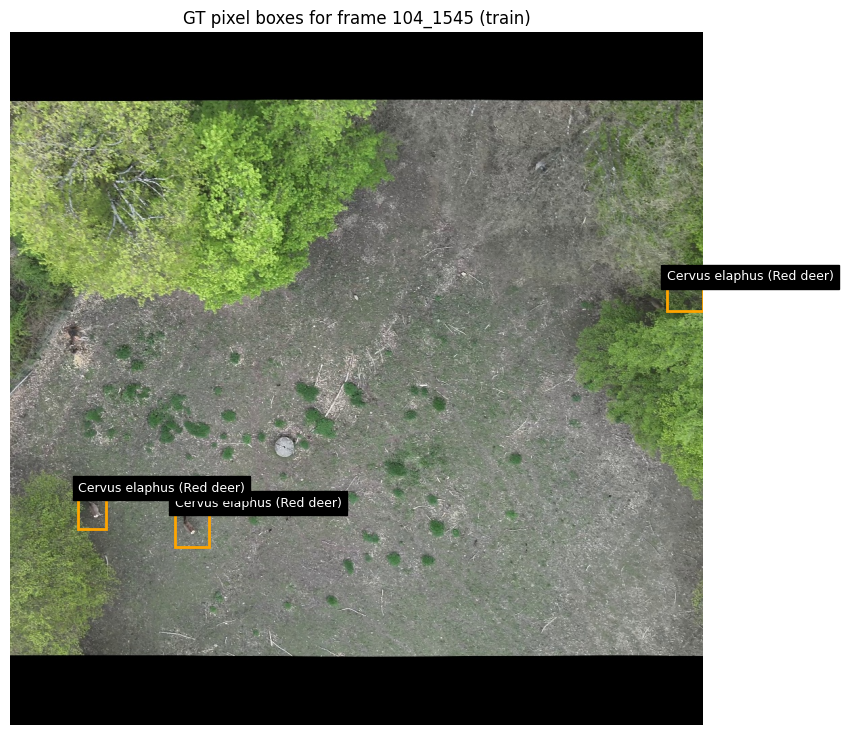

GT boxes shown: 3
Image path: C:\Users\jojog\Documents\School\Semester_4\CIV4\CIV4-WhoS-Where\data\rgb_images\train\104_1545.jpg


In [18]:
target_frame = 1545
frame_rows = gt[gt["frame"] == target_frame].copy()

if frame_rows.empty:
    print(f"No GT rows found for frame {target_frame} in {frame_id}_gt.txt")
else:
    cwd = Path.cwd().resolve()
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

    frame_key = f"{frame_id}_{target_frame}"
    split, image_path, _ = resolve_frame_paths(frame_key, project_root)

    image = Image.open(image_path).convert("RGB")

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)

    for _, row in frame_rows.iterrows():
        x = float(row["bb_left"])
        y = float(row["bb_top"])
        w = float(row["bb_width"])
        h = float(row["bb_height"])

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="orange",
            facecolor="none",
        )
        ax.add_patch(rect)

        label = None
        if "species" in frame_rows.columns:
            label = str(row["species"])
        elif "class_id" in frame_rows.columns:
            label = f"class {int(row['class_id'])}"

        if label:
            ax.text(
                x,
                max(2, y - 6),
                label,
                color="white",
                fontsize=9,
                backgroundcolor="black",
            )

    ax.set_title(f"GT pixel boxes for frame {frame_key} ({split})")
    ax.axis("off")
    plt.show()

    print(f"GT boxes shown: {len(frame_rows)}")
    print(f"Image path: {image_path}")

## Cutting out the clustered group

**What this section does**

1. Load the image and the bounding box
2. Convert the boudning box coordinates to pixels
3. Groups animals into clusters
4. Cut out the clusters

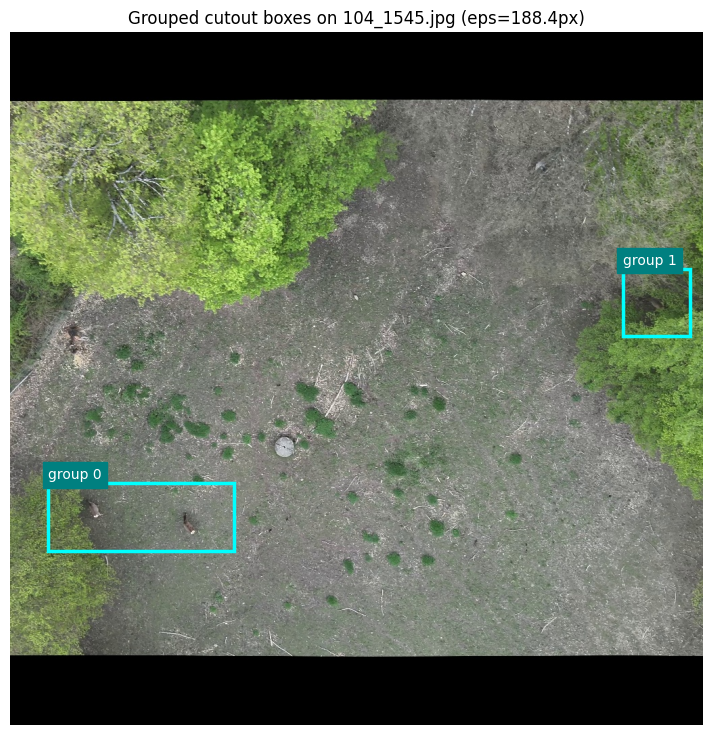

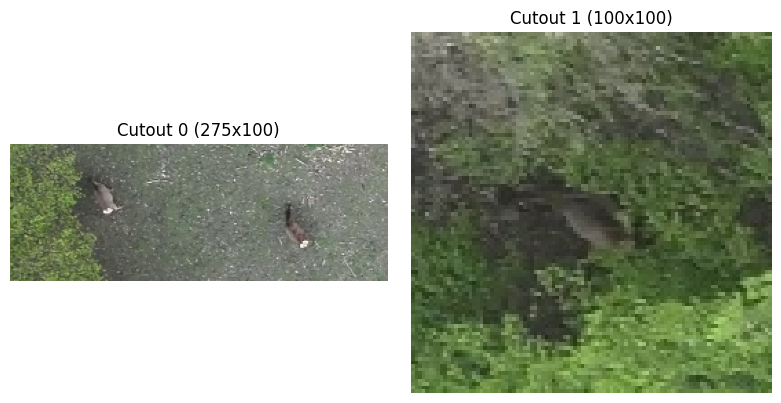

Detections: 3
Groups found: 2
Clustering eps (pixels): 188.36


In [35]:
from math import hypot


def _connected_components(points, eps):
    """Simple radius-graph clustering (DBSCAN-style with min_samples=1)."""
    n = len(points)
    visited = [False] * n
    clusters = []

    for i in range(n):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        component = []

        while stack:
            u = stack.pop()
            component.append(u)
            ux, uy = points[u]

            for v in range(n):
                if visited[v]:
                    continue
                vx, vy = points[v]
                if hypot(ux - vx, uy - vy) <= eps:
                    visited[v] = True
                    stack.append(v)

        clusters.append(component)

    return clusters


def cluster_group_cutouts(image_path, label_path, eps_scale=3.0, margin_ratio=0.2, min_cluster_size=1, min_bounding_bluster_size = 100):
    """
    Cluster animal detections into spatial groups and return cropped group images.

    Args:
        image_path: Path to image file.
        label_path: Path to YOLO label file (class x_center y_center width height).
        eps_scale: Radius scale for clustering based on median box diagonal.
        margin_ratio: Extra margin around each grouped crop.
        min_cluster_size: Minimum number of detections required for a cluster.

    Returns:
        dict with:
            - image: PIL image
            - detections: parsed detections with pixel boxes
            - clusters: list of cluster index lists
            - group_boxes: list of (x1, y1, x2, y2)
            - cutouts: list of PIL cropped images
            - eps_px: clustering radius in pixels
    """
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    detections = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id, x_c, y_c, w, h = line.split()
            class_id = int(class_id)
            x_c = float(x_c)
            y_c = float(y_c)
            w = float(w)
            h = float(h)

            x_min, y_min, box_w, box_h = yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
            x_max = x_min + box_w
            y_max = y_min + box_h

            detections.append(
                {
                    "class_id": class_id,
                    "x_center": x_c * img_w,
                    "y_center": y_c * img_h,
                    "x_min": x_min,
                    "y_min": y_min,
                    "x_max": x_max,
                    "y_max": y_max,
                    "box_w": box_w,
                    "box_h": box_h,
                }
            )

    if not detections:
        return {
            "image": image,
            "detections": [],
            "clusters": [],
            "group_boxes": [],
            "cutouts": [],
            "eps_px": 0.0,
        }

    diagonals = [hypot(d["box_w"], d["box_h"]) for d in detections]
    diagonals_sorted = sorted(diagonals)
    median_diag = diagonals_sorted[len(diagonals_sorted) // 2]
    eps_px = max(1.0, eps_scale * median_diag)

    points = [(d["x_center"], d["y_center"]) for d in detections]
    clusters = _connected_components(points, eps_px)
    clusters = [c for c in clusters if len(c) >= min_cluster_size]

    group_boxes = []
    cutouts = []

    for cluster in clusters:
        x1 = min(detections[i]["x_min"] for i in cluster)
        y1 = min(detections[i]["y_min"] for i in cluster)
        x2 = max(detections[i]["x_max"] for i in cluster)
        y2 = max(detections[i]["y_max"] for i in cluster)

        bw = x2 - x1
        bh = y2 - y1
        mx = bw * margin_ratio
        if bw < min_bounding_bluster_size and bw +2 * mx < min_bounding_bluster_size:
            dif = min_bounding_bluster_size - bw
            mx = dif/2
        my = bh * margin_ratio
        if bh < min_bounding_bluster_size and bh +2 * my < min_bounding_bluster_size:
            dif = min_bounding_bluster_size - bh
            my = dif/2

        x1 = max(0, int(round(x1 - mx)))
        y1 = max(0, int(round(y1 - my)))
        x2 = min(img_w, int(round(x2 + mx)))
        y2 = min(img_h, int(round(y2 + my)))

        group_boxes.append((x1, y1, x2, y2))
        cutouts.append(image.crop((x1, y1, x2, y2)))

    return {
        "image": image,
        "detections": detections,
        "clusters": clusters,
        "group_boxes": group_boxes,
        "cutouts": cutouts,
        "eps_px": eps_px,
    }


# Demo on frame 55_4650
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

demo_image_path = project_root / "data" / "rgb_images" / "train" / "104_1545.jpg"
demo_label_path = project_root / "data" / "labels_matched_rgb" / "train" / "104_1545.txt"

result = cluster_group_cutouts(
    image_path=demo_image_path,
    label_path=demo_label_path,
    eps_scale=3.0,
    margin_ratio=0.25,
    min_cluster_size=1,
)

# Show original image with grouped cutout boxes.
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(result["image"])
for i, (x1, y1, x2, y2) in enumerate(result["group_boxes"]):
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor="cyan", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(2, y1 - 6), f"group {i}", color="white", fontsize=10, backgroundcolor="teal")
ax.set_title(f"Grouped cutout boxes on {demo_image_path.name} (eps={result['eps_px']:.1f}px)")
ax.axis("off")
plt.show()

# Show each extracted cutout.
cutouts = result["cutouts"]
if cutouts:
    cols = min(4, len(cutouts))
    rows = (len(cutouts) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for i, crop in enumerate(cutouts):
        axes[i].imshow(crop)
        axes[i].set_title(f"Cutout {i} ({crop.size[0]}x{crop.size[1]})")
        axes[i].axis("off")

    for j in range(len(cutouts), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

print(f"Detections: {len(result['detections'])}")
print(f"Groups found: {len(result['clusters'])}")
print(f"Clustering eps (pixels): {result['eps_px']:.2f}")

## Find Frame with 2 groups

Found frame: 104_1545
Groups found: 2
Files checked: 65


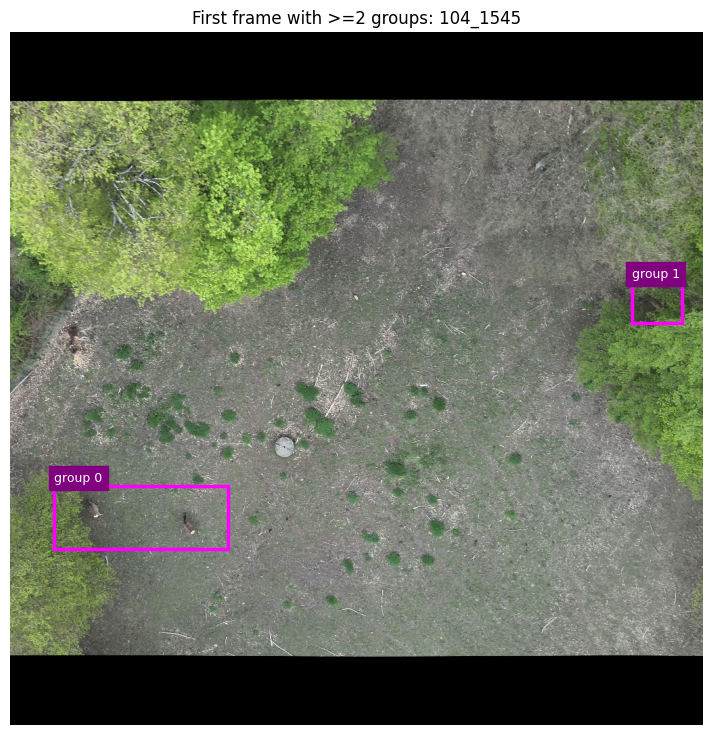

In [ ]:
def find_frame_with_min_groups(
    labels_dir,
    images_dir,
    min_groups=2,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    max_files=None,
):
    """
    Scan YOLO label files and return the first frame that contains at least `min_groups` clusters.

    Returns:
        dict with keys: frame_id, image_path, label_path, groups_found, result
        or None if no matching frame is found.
    """
    labels_dir = Path(labels_dir)
    images_dir = Path(images_dir)

    label_files = sorted(labels_dir.glob("*.txt"))
    checked = 0

    for label_file in label_files:
        frame_id = label_file.stem
        image_file = images_dir / f"{frame_id}.jpg"

    return None


# Demo search in test split.
search_labels_dir = project_root / "data" / "labels_matched_rgb" / "train"
search_images_dir = project_root / "data" / "rgb_images" / "train"

match = find_frame_with_min_groups(
    labels_dir=search_labels_dir,
    images_dir=search_images_dir,
    min_groups=2,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
)

if match is None:
    print("No frame with at least 2 groups found using current parameters.")
else:
    print(f"Found frame: {match['frame_id']}")
    print(f"Groups found: {match['groups_found']}")
    print(f"Files checked: {match['files_checked']}")

    # Optional quick visualization of found grouped boxes.
    found_result = match["result"]
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(found_result["image"])

    for i, (x1, y1, x2, y2) in enumerate(found_result["group_boxes"]):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor="magenta", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(2, y1 - 6), f"group {i}", color="white", fontsize=9, backgroundcolor="purple")

    ax.set_title(f"First frame with >=2 groups: {match['frame_id']}")
    ax.axis("off")
    plt.show()

In [1]:
from collections import defaultdict

In [10]:
def find_frame_with_min_groups(
    labels_dir,
):
    """
    Scan YOLO label files and return the first frame that contains at least `min_groups` clusters.

    Returns:
        dict with keys: frame_id, image_path, label_path, groups_found, result
        or None if no matching frame is found.
    """
    labels_dir = Path(labels_dir)

    label_files = sorted(labels_dir.glob("*.txt"))

    classes = set()
    for label_file in label_files:
        frame_id = label_file.stem

        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                class_id, _, _, _, _ = line.split()
                classes.add(class_id)

    return classes

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
search_labels_dir = project_root / "data" / "labels_matched_rgb" / "test"

matched = find_frame_with_min_groups(labels_dir=search_labels_dir)
matched

{'0'}

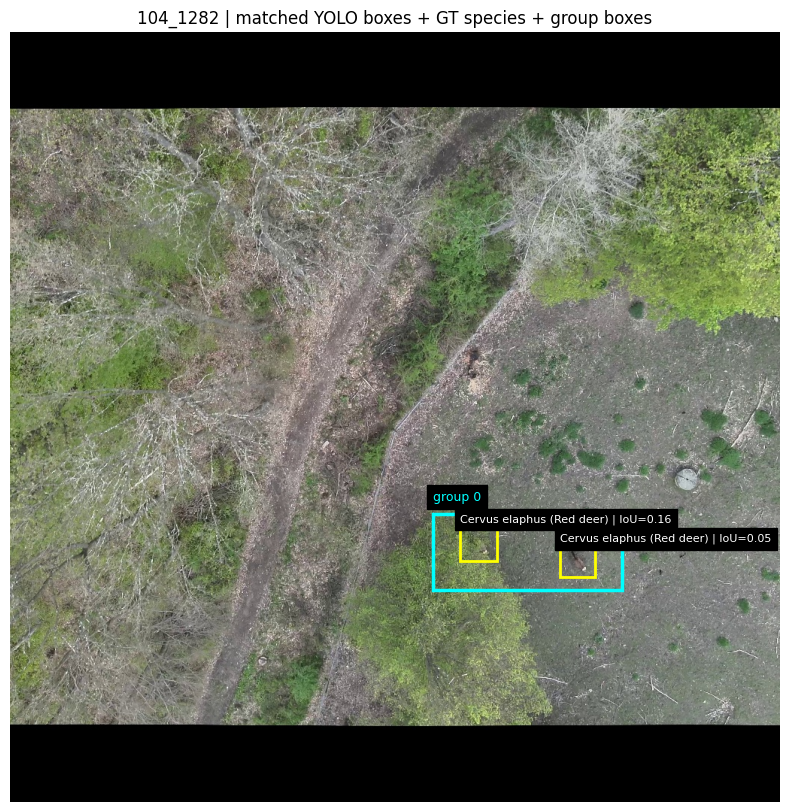

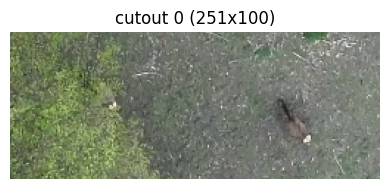

Frame key: 104_1282
Split: train
Matched detections with species: 2
Groups: 1
Returned cutouts: 1


In [7]:
from math import hypot
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


def build_species_labeled_group_cutouts(
    image_id,
    project_root=None,
    min_cutout_size=100,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    min_iou=0.0,
    return_debug=False,
):
    """Assign GT species to YOLO boxes, cluster them, and return cluster cutouts.

    The function expects image/label naming like "<flight>_<frame>" (e.g., "104_1545").
    For names without underscore, it falls back to first 3 digits = flight and the rest = frame.
    """

    def _parse_image_id(raw_id):
        stem = str(raw_id).strip()
        for suffix in (".jpg", ".jpeg", ".png", ".txt"):
            if stem.lower().endswith(suffix):
                stem = stem[: -len(suffix)]
                break

        if "_" in stem:
            flight_part, frame_part = stem.split("_", 1)
        else:
            digits = "".join(ch for ch in stem if ch.isdigit())
            if len(digits) < 4:
                raise ValueError(f"Cannot parse image_id '{raw_id}'. Expected '<flight>_<frame>' or 3+ digits.")
            flight_part, frame_part = digits[:3], digits[3:]

        if not flight_part.isdigit() or not frame_part.isdigit():
            raise ValueError(f"Invalid image_id '{raw_id}'. Flight and frame must be numeric.")

        flight_num = int(flight_part)
        frame_num = int(frame_part)
        frame_key = f"{flight_num}_{frame_num}"
        return flight_num, frame_num, frame_key

    def _resolve_frame_paths(frame_key, root):
        for split in ("train", "val", "test"):
            base_img = root / "data" / "rgb_images" / split
            base_lbl = root / "data" / "labels_matched_rgb" / split

            image_path = None
            for ext in (".jpg", ".jpeg", ".png"):
                candidate = base_img / f"{frame_key}{ext}"
                if candidate.exists():
                    image_path = candidate
                    break

            label_path = base_lbl / f"{frame_key}.txt"
            if image_path is not None and label_path.exists():
                return split, image_path, label_path

        raise FileNotFoundError(f"Could not find matching image and label txt for frame '{frame_key}'.")

    def _iou(a, b):
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b

        inter_x1 = max(ax1, bx1)
        inter_y1 = max(ay1, by1)
        inter_x2 = min(ax2, bx2)
        inter_y2 = min(ay2, by2)

        inter_w = max(0.0, inter_x2 - inter_x1)
        inter_h = max(0.0, inter_y2 - inter_y1)
        inter_area = inter_w * inter_h

        area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
        area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
        union = area_a + area_b - inter_area
        return 0.0 if union <= 0 else inter_area / union

    def _connected_components(points, eps):
        n = len(points)
        visited = [False] * n
        clusters = []

        for i in range(n):
            if visited[i]:
                continue
            stack = [i]
            visited[i] = True
            component = []

            while stack:
                u = stack.pop()
                component.append(u)
                ux, uy = points[u]

                for v in range(n):
                    if visited[v]:
                        continue
                    vx, vy = points[v]
                    if hypot(ux - vx, uy - vy) <= eps:
                        visited[v] = True
                        stack.append(v)

            clusters.append(component)

        return clusters

    if project_root is None:
        cwd = Path.cwd().resolve()
        project_root = cwd.parent if cwd.name == "notebooks" else cwd

    flight_num, frame_num, frame_key = _parse_image_id(image_id)
    split, image_path, label_path = _resolve_frame_paths(frame_key, project_root)

    headings_path = project_root / "data" / "gt_headings.txt"
    with open(headings_path, "r", encoding="utf-8") as f:
        headings = [h.strip() for h in f.readline().split(";")]

    gt_path = project_root / "data" / "gt" / f"{flight_num}_gt.txt"
    gt_df = pd.read_csv(gt_path, names=headings)
    gt_rows = gt_df[gt_df["frame"] == frame_num].copy()

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    yolo_boxes = []
    with open(label_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            class_id, x_c, y_c, w, h = line.split()
            class_id = int(class_id)
            x_c, y_c, w, h = map(float, (x_c, y_c, w, h))

            bw = w * img_w
            bh = h * img_h
            x1 = (x_c * img_w) - (bw / 2.0)
            y1 = (y_c * img_h) - (bh / 2.0)
            x2 = x1 + bw
            y2 = y1 + bh

            yolo_boxes.append(
                {
                    "txt_idx": idx,
                    "yolo_class_id": class_id,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "xc": (x1 + x2) / 2.0,
                    "yc": (y1 + y2) / 2.0,
                }
            )

    if gt_rows.empty or not yolo_boxes:
        cutouts = []
        if return_debug:
            return cutouts, {
                "image": image,
                "split": split,
                "image_path": image_path,
                "label_path": label_path,
                "gt_rows": gt_rows,
                "matched_boxes": [],
                "group_boxes": [],
                "clusters": [],
                "frame_key": frame_key,
            }
        return cutouts

    gt_rows = gt_rows.reset_index(drop=True)
    gt_rows["gx1"] = gt_rows["bb_left"].astype(float)
    gt_rows["gy1"] = gt_rows["bb_top"].astype(float)
    gt_rows["gx2"] = gt_rows["gx1"] + gt_rows["bb_width"].astype(float)
    gt_rows["gy2"] = gt_rows["gy1"] + gt_rows["bb_height"].astype(float)
    gt_rows["gxc"] = (gt_rows["gx1"] + gt_rows["gx2"]) / 2.0
    gt_rows["gyc"] = (gt_rows["gy1"] + gt_rows["gy2"]) / 2.0

    candidates = []
    for g_idx, g in gt_rows.iterrows():
        g_box = (g["gx1"], g["gy1"], g["gx2"], g["gy2"])
        for y_idx, y in enumerate(yolo_boxes):
            y_box = (y["x1"], y["y1"], y["x2"], y["y2"])
            iou = _iou(g_box, y_box)
            if iou < min_iou:
                continue

            dist = hypot(g["gxc"] - y["xc"], g["gyc"] - y["yc"])
            candidates.append((float(iou), float(dist), int(g_idx), int(y_idx)))

    candidates.sort(key=lambda x: (-x[0], x[1]))

    used_g = set()
    used_y = set()
    matched_boxes = []

    for iou, dist, g_idx, y_idx in candidates:
        if g_idx in used_g or y_idx in used_y:
            continue

        used_g.add(g_idx)
        used_y.add(y_idx)

        g = gt_rows.iloc[g_idx]
        y = yolo_boxes[y_idx]

        matched_boxes.append(
            {
                "txt_idx": y["txt_idx"],
                "yolo_class_id": y["yolo_class_id"],
                "species": g.get("species", None),
                "track_id": g.get("track_id", None),
                "iou": iou,
                "center_dist": dist,
                "x1": y["x1"],
                "y1": y["y1"],
                "x2": y["x2"],
                "y2": y["y2"],
                "xc": y["xc"],
                "yc": y["yc"],
            }
        )

    if not matched_boxes:
        cutouts = []
        if return_debug:
            return cutouts, {
                "image": image,
                "split": split,
                "image_path": image_path,
                "label_path": label_path,
                "gt_rows": gt_rows,
                "matched_boxes": matched_boxes,
                "group_boxes": [],
                "clusters": [],
                "frame_key": frame_key,
            }
        return cutouts

    diagonals = [hypot(m["x2"] - m["x1"], m["y2"] - m["y1"]) for m in matched_boxes]
    median_diag = sorted(diagonals)[len(diagonals) // 2]
    eps_px = max(1.0, eps_scale * median_diag)

    points = [(m["xc"], m["yc"]) for m in matched_boxes]
    clusters = _connected_components(points, eps_px)
    clusters = [c for c in clusters if len(c) >= min_cluster_size]

    group_boxes = []
    cutouts = []

    for cluster in clusters:
        x1 = min(matched_boxes[i]["x1"] for i in cluster)
        y1 = min(matched_boxes[i]["y1"] for i in cluster)
        x2 = max(matched_boxes[i]["x2"] for i in cluster)
        y2 = max(matched_boxes[i]["y2"] for i in cluster)

        bw = x2 - x1
        bh = y2 - y1

        mx = bw * margin_ratio
        my = bh * margin_ratio

        if bw + 2 * mx < min_cutout_size:
            mx = (min_cutout_size - bw) / 2.0
        if bh + 2 * my < min_cutout_size:
            my = (min_cutout_size - bh) / 2.0

        gx1 = max(0, int(round(x1 - mx)))
        gy1 = max(0, int(round(y1 - my)))
        gx2 = min(img_w, int(round(x2 + mx)))
        gy2 = min(img_h, int(round(y2 + my)))

        group_boxes.append((gx1, gy1, gx2, gy2))
        cutouts.append(image.crop((gx1, gy1, gx2, gy2)))

    if return_debug:
        return cutouts, {
            "image": image,
            "split": split,
            "image_path": image_path,
            "label_path": label_path,
            "gt_rows": gt_rows,
            "matched_boxes": matched_boxes,
            "group_boxes": group_boxes,
            "clusters": clusters,
            "eps_px": eps_px,
            "frame_key": frame_key,
        }

    return cutouts


# Demo
example_image_id = "104_1282"
cutouts, debug = build_species_labeled_group_cutouts(
    image_id=example_image_id,
    min_cutout_size=100,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    min_iou=0.0,
    return_debug=True,
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(debug["image"])

for m in debug["matched_boxes"]:
    rect = patches.Rectangle(
        (m["x1"], m["y1"]),
        m["x2"] - m["x1"],
        m["y2"] - m["y1"],
        linewidth=2,
        edgecolor="yellow",
        facecolor="none",
    )
    ax.add_patch(rect)

    species = "unknown" if pd.isna(m["species"]) else str(m["species"])
    ax.text(
        m["x1"],
        max(2, m["y1"] - 6),
        f"{species} | IoU={m['iou']:.2f}",
        color="white",
        fontsize=8,
        backgroundcolor="black",
    )

for i, (x1, y1, x2, y2) in enumerate(debug["group_boxes"]):
    group_rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2.5,
        edgecolor="cyan",
        facecolor="none",
    )
    ax.add_patch(group_rect)
    ax.text(x1, max(2, y1 - 18), f"group {i}", color="cyan", fontsize=9, backgroundcolor="black")

ax.set_title(f"{example_image_id} | matched YOLO boxes + GT species + group boxes")
ax.axis("off")
plt.show()

if cutouts:
    cols = min(4, len(cutouts))
    rows = (len(cutouts) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for i, crop in enumerate(cutouts):
        axes[i].imshow(crop)
        axes[i].set_title(f"cutout {i} ({crop.size[0]}x{crop.size[1]})")
        axes[i].axis("off")

    for j in range(len(cutouts), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

print(f"Frame key: {debug['frame_key']}")
print(f"Split: {debug['split']}")
print(f"Matched detections with species: {len(debug['matched_boxes'])}")
print(f"Groups: {len(debug['group_boxes'])}")
print(f"Returned cutouts: {len(cutouts)}")

In [5]:
from collections import Counter
import re


def save_split_group_cutouts_by_species(
    split,
    output_root=None,
    project_root=None,
    min_cutout_size=100,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    min_iou=0.0,
    max_images=None,
):
    """Process one split and save group cutouts into split/species folders.

    Saved filename format: <frame_key>_group<group_idx>.jpg
    """

    def _safe_species_name(species):
        name = str(species).strip() if species is not None else "unknown"
        if not name or name.lower() == "nan":
            name = "unknown"
        name = re.sub(r'[<>:"/\\|?*]+', "_", name)
        name = re.sub(r"\s+", " ", name).strip().rstrip(".")
        return name or "unknown"

    if project_root is None:
        cwd = Path.cwd().resolve()
        project_root = cwd.parent if cwd.name == "notebooks" else cwd

    if output_root is None:
        output_root = project_root / "data" / "group_cutouts_by_species"
    else:
        output_root = Path(output_root)

    labels_dir = project_root / "data" / "labels_matched_rgb" / split
    if not labels_dir.exists():
        raise FileNotFoundError(f"Split labels folder not found: {labels_dir}")

    label_files = sorted(labels_dir.glob("*.txt"))
    if max_images is not None:
        label_files = label_files[:max_images]

    saved_rows = []

    for label_path in label_files:
        image_id = label_path.stem

        try:
            cutouts, debug = build_species_labeled_group_cutouts(
                image_id=image_id,
                project_root=project_root,
                min_cutout_size=min_cutout_size,
                eps_scale=eps_scale,
                margin_ratio=margin_ratio,
                min_cluster_size=min_cluster_size,
                min_iou=min_iou,
                return_debug=True,
            )
        except Exception as e:
            saved_rows.append(
                {
                    "split": split,
                    "frame_key": image_id,
                    "group_idx": pd.NA,
                    "species": "error",
                    "save_path": pd.NA,
                    "width": pd.NA,
                    "height": pd.NA,
                    "status": f"error: {e}",
                }
            )
            continue

        if not cutouts:
            saved_rows.append(
                {
                    "split": split,
                    "frame_key": debug["frame_key"],
                    "group_idx": pd.NA,
                    "species": "none",
                    "save_path": pd.NA,
                    "width": pd.NA,
                    "height": pd.NA,
                    "status": "no_groups",
                }
            )
            continue

        for group_idx, cutout in enumerate(cutouts):
            cluster_indices = debug["clusters"][group_idx] if group_idx < len(debug["clusters"]) else []

            species_values = []
            for det_idx in cluster_indices:
                if 0 <= det_idx < len(debug["matched_boxes"]):
                    species_values.append(debug["matched_boxes"][det_idx].get("species"))

            species_values = [s for s in species_values if s is not None and str(s).lower() != "nan"]
            if species_values:
                species_label = Counter(species_values).most_common(1)[0][0]
            else:
                species_label = "unknown"

            safe_species = _safe_species_name(species_label)
            target_dir = output_root / split / safe_species
            target_dir.mkdir(parents=True, exist_ok=True)

            out_name = f"{debug['frame_key']}_group{group_idx}.jpg"
            out_path = target_dir / out_name
            cutout.save(out_path)

            saved_rows.append(
                {
                    "split": split,
                    "frame_key": debug["frame_key"],
                    "group_idx": group_idx,
                    "species": species_label,
                    "save_path": str(out_path),
                    "width": cutout.size[0],
                    "height": cutout.size[1],
                    "status": "saved",
                }
            )

    return pd.DataFrame(saved_rows)


# Demo: run on a small subset first. Increase max_images or set None for full split.
save_results = save_split_group_cutouts_by_species(
    split="train",
    output_root=Path("../data/group_cutouts_by_species"),
    min_cutout_size=100,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    min_iou=0.0,
    max_images=50,
)

status_counts = save_results["status"].value_counts(dropna=False)
print(f"Rows: {len(save_results)}")
print(status_counts.to_string())
print(f"Saved cutouts: {(save_results['status'] == 'saved').sum()}")
print(f"Output root: {Path('../data/group_cutouts_by_species').resolve()}")

save_results[save_results["status"].str.startswith("error", na=False)].head(10)

Rows: 50
status
saved    50
Saved cutouts: 50
Output root: C:\Users\jojog\Documents\School\Semester_4\CIV4\CIV4-WhoS-Where\data\group_cutouts_by_species


,split,frame_key,group_idx,species,save_path,width,height,status
